In [ ]:
from collections.abc import MutableMapping

In [ ]:
# Helper: Flatten nested configs
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, MutableMapping):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


**THE FOLLOWING LOADS IMAN'S RESULTS TO WANDB**

In [ ]:
import wandb
import os
import pandas as pd
import json


# Configuration
ENTITY = "loss-of-plasticity"
PROJECT = "continual-learning-experiments"


log_dir = "/Users/giulialanzillotta/Downloads/results_plasticity"  # Folder where your .csv/.json files are

# Get all run_ids from filenames
run_ids = set(f.split('.')[0] for f in os.listdir(log_dir) if f.endswith(".json"))

for run_id in run_ids:
    json_path = os.path.join(log_dir, f"{run_id}.json")
    csv_path = os.path.join(log_dir, f"{run_id}.csv")

    # Load config and summary data
    with open(json_path, "r") as f:
        run_data = json.load(f)

    config = run_data.get("config", {})
    summary = run_data.get("summary", {})

    # Start new run with the same run_id and config
    run = wandb.init(project=PROJECT, entity=ENTITY, config=config, name=run_id, reinit=True, tags=["iman","main"])

    # Log history from CSV
    df = pd.read_csv(csv_path)
    for _, row in df.iterrows():
        # Remove any unnamed index columns
        log_data = {k: v for k, v in row.items() if not k.startswith("Unnamed")}
        wandb.log(log_data)

    # Log summary metrics at the end
    wandb.run.summary.update(summary)

    run.finish()


**THE FOLLOWING CODE LOADS IMAN'S DATA TO A PANDAS DATAFRAME**

In [ ]:
import os
import json
import pandas as pd

log_dirs = ["/Users/giulialanzillotta/Downloads/results_plasticity", "/Users/giulialanzillotta/Downloads/results_plasticity_not_affine"]  # Folder where your .csv/.json files are
all_rows = []
skipped = 0
total = 0

FILTERS = {
    # "model.normalization": "none",
    # "model.dropout_p": 0,
    "model.name": "vit"
}


for log_dir in log_dirs:
    all_files = os.listdir(log_dir)

    # Identify run_ids from available .json files
    run_ids = set(f.split('.')[0] for f in all_files if f.endswith(".json"))



    for run_id in run_ids:
        json_path = os.path.join(log_dir, f"{run_id}.json")
        csv_path = os.path.join(log_dir, f"{run_id}.csv")
        print(csv_path)
        print(json_path)

        # Skip if either file is missing
        if not os.path.exists(csv_path) or not os.path.exists(json_path):
            continue

        # Load config from .json
        with open(json_path, "r") as f:
            json_file = json.load(f)

        config = flatten_dict({k: v for k, v in json_file.items() if not k.startswith('_')})

        
        if any([config.get(k) != v for k,v in FILTERS.items()]):
            print(f"Skipping {run_id}")
            skipped+=1
            continue

        # Load run history from .csv
        try: df = pd.read_csv(csv_path)
        except pd.errors.EmptyDataError: 
            skipped+=1
            continue

        # Add run_id and config to each row
        df["run_id"] = run_id
        
        for key, value in config.items():
            if isinstance(value, (int, float, str, bool)) or value is None:
                df[key] = value
            else:
                # Skip non-scalar config values (e.g., lists, dicts)
                print(f"Skipping non-scalar config key: {key}")

        all_rows.append(df)
        total+=1

# Combine all runs into a single DataFrame
combined_df = pd.concat(all_rows, ignore_index=True)

print(f"Skipped {skipped}, saved {total}")
#print(combined_df.head())


In [ ]:
combined_df

In [ ]:
combined_df.to_pickle("vit_df.pkl")

In [ ]:

vit_df = pd.read_pickle('vit_df.pkl')
len(vit_df)


In [ ]:
vit_df.columns.tolist()

In [ ]:
vit_df["optimizer.lr"].unique()

In [ ]:
df_all = combined_df

Download the data from wandb:

In [3]:
import wandb
import pandas as pd

# Configuration
ENTITY = "loss-of-plasticity"
# PROJECT = "continual-learning-experiments"
PROJECT = "cloning"

# filter runs by these filters
FILTERS = {
    "tags": "main",
    # "config.dataset.name":"slowlychangingregression"
}

# Initialize API
api = wandb.Api()

# Fetch runs
runs = api.runs(f"{ENTITY}/{PROJECT}", per_page=1000, filters=FILTERS)

# Collect all historical data
all_histories = []

for run in runs:
    if run.state != "finished":
        print(f"Skipping run {run.name} ({run.id}) — state: {run.state}")
        continue
    
    print(f"Downloading history for run: {run.name} ({run.id})")
    try:
        # Fetch full history (pagination is handled automatically here)
        history = run.history(samples=100000)  # Optional: increase samples if needed
        history["run_id"] = run.id
        history["run_name"] = run.name

        config = flatten_dict({k: v for k, v in run.config.items() if not k.startswith('_')})

        for key, value in config.items():
            if isinstance(value, (int, float, str, bool)) or value is None:
                history[key] = value
            else:
                # Skip non-scalar config values (e.g., lists, dicts)
                print(f"Skipping non-scalar config key: {key}")


        all_histories.append(history)

    except Exception as e:
        print(f"Failed to download history for run {run.id}: {e}")

# Concatenate all histories into a single DataFrame
df_all = pd.concat(all_histories, ignore_index=True)

# Optional: Save to CSV
# df_all.to_csv("wandb_all_history.csv", index=False)

# Preview
df_all.head()


Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_filters
Skipping non-scalar config key: wandb_tags
Skipping non-scalar config key: model.hidden_sizes
Skipping non-scalar config key: metrics.monitor_f

,base_train/layers.norm_0/mean_of_stds,base_val/layers.linear_3/std_of_means,base_train/layers.norm_2/act_means_hist,base_train/layers.linear_0/act_stds_hist,base_val/layers.linear_2/std_of_stds,base_val/layers.linear_3/mean_of_means,base_val/layers.norm_4/std_of_stds,base_train/layers.linear_1/std_of_stds,base_val/layers.linear_3/act_means_hist,base_train/layers.norm_3/act_stds_hist,...,optimizer.name,optimizer.momentum,optimizer.nesterov,optimizer.dampening,optimizer.noise_decay,optimizer.noise_scale,optimizer.weight_decay,optimizer.reinit_optimizer,use_wandb,wandb_project
0,0.763818,0.06334,"{'_type': 'histogram', 'packedBins': {'min': -...","{'packedBins': {'size': 0.011440746020525694, ...",0.012907,0.001011,0.001868,0.034729,"{'packedBins': {'size': 0.004449483240023255, ...","{'_type': 'histogram', 'packedBins': {'min': 0...",...,noisysgd,0.9,False,0,0.999,0.01,0,False,True,cloning
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,noisysgd,0.9,False,0,0.999,0.01,0,False,True,cloning
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,noisysgd,0.9,False,0,0.999,0.01,0,False,True,cloning
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,noisysgd,0.9,False,0,0.999,0.01,0,False,True,cloning
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,noisysgd,0.9,False,0,0.999,0.01,0,False,True,cloning


In [4]:
len(df_all)

980850

### Organizing the hierarchical column structure 

In [5]:
all_columns = {}
for col in df_all.columns:
    parts = col.split('/')
    if len(parts) == 3:
        type_ = parts[0]
        layer = parts[1]
        quantity = parts[2]
        all_columns[(type_, quantity, layer)] = col
    
all_columns

{('base_train',
  'mean_of_stds',
  'layers.norm_0'): 'base_train/layers.norm_0/mean_of_stds',
 ('base_val',
  'std_of_means',
  'layers.linear_3'): 'base_val/layers.linear_3/std_of_means',
 ('base_train',
  'act_means_hist',
  'layers.norm_2'): 'base_train/layers.norm_2/act_means_hist',
 ('base_train',
  'act_stds_hist',
  'layers.linear_0'): 'base_train/layers.linear_0/act_stds_hist',
 ('base_val',
  'std_of_stds',
  'layers.linear_2'): 'base_val/layers.linear_2/std_of_stds',
 ('base_val',
  'mean_of_means',
  'layers.linear_3'): 'base_val/layers.linear_3/mean_of_means',
 ('base_val',
  'std_of_stds',
  'layers.norm_4'): 'base_val/layers.norm_4/std_of_stds',
 ('base_train',
  'std_of_stds',
  'layers.linear_1'): 'base_train/layers.linear_1/std_of_stds',
 ('base_val',
  'act_means_hist',
  'layers.linear_3'): 'base_val/layers.linear_3/act_means_hist',
 ('base_train',
  'act_stds_hist',
  'layers.norm_3'): 'base_train/layers.norm_3/act_stds_hist',
 ('base_train',
  'std_of_stds',
  'la

In [6]:
nested_columns = {}
for key, value in all_columns.items():
    k0, k1, k2 = key
    if k0 not in nested_columns:
        nested_columns[k0] = {}
    if k1 not in nested_columns[k0]:
        nested_columns[k0][k1] = {}
    nested_columns[k0][k1][k2] = value
nested_columns

{'base_train': {'mean_of_stds': {'layers.norm_0': 'base_train/layers.norm_0/mean_of_stds',
   'layers.norm_2': 'base_train/layers.norm_2/mean_of_stds',
   'layers.linear_0': 'base_train/layers.linear_0/mean_of_stds',
   'layers.out': 'base_train/layers.out/mean_of_stds',
   'layers.norm_1': 'base_train/layers.norm_1/mean_of_stds',
   'layers.act_2': 'base_train/layers.act_2/mean_of_stds',
   'layers.linear_1': 'base_train/layers.linear_1/mean_of_stds',
   'layers.act_4': 'base_train/layers.act_4/mean_of_stds',
   'layers.linear_4': 'base_train/layers.linear_4/mean_of_stds',
   'layers.act_3': 'base_train/layers.act_3/mean_of_stds',
   'layers.linear_3': 'base_train/layers.linear_3/mean_of_stds',
   'layers.act_0': 'base_train/layers.act_0/mean_of_stds',
   'layers.act_1': 'base_train/layers.act_1/mean_of_stds',
   'layers.linear_2': 'base_train/layers.linear_2/mean_of_stds',
   'layers.norm_3': 'base_train/layers.norm_3/mean_of_stds',
   'layers.norm_4': 'base_train/layers.norm_4/mean_

In [10]:
nested_columns.keys()

dict_keys(['base_train', 'base_val', 'cloned_2x_val', 'cloned_2x_train'])

In [14]:
nested_columns["cloned_2x_train"]["mean"]

{'cloning_r2': 'cloned_2x_train/cloning_r2/mean'}

### Filtering the dataframe

In [7]:
main_df = df_all

In [ ]:
# calculate how many nan rows there are for each column
nan_counts = main_df.isna().sum()
# Display the columns with more than 0 NaN values
nan_columns = nan_counts[nan_counts > 0].index.tolist()
print("Columns with NaN values:")
for col in nan_columns:
    print(f"{col}: {nan_counts[col]/len(main_df)} % NaN values")

In [ ]:
# # drop the columns with more than 90% nan values
# nan_threshold = 0.9
# nan_counts = main_df.isna().sum()
# nan_columns = nan_counts[nan_counts > len(main_df) * nan_threshold].index.tolist()
# print("Dropping columns with more than 90% NaN values:")
# for col in nan_columns:
#     print(f"{col}: {nan_counts[col]} NaN values")
# main_df = main_df.drop(columns=nan_columns)

In [ ]:
# # print all the columns with their nan values (0 if no nan values)
# nan_counts = main_df.isna().sum()
# print("Columns with NaN values:")
# for col in main_df.columns:
#     print(f"{col}: {nan_counts[col]} NaN values")

### Average values across layers

In [15]:
nested_columns

{'base_train': {'mean_of_stds': {'layers.norm_0': 'base_train/layers.norm_0/mean_of_stds',
   'layers.norm_2': 'base_train/layers.norm_2/mean_of_stds',
   'layers.linear_0': 'base_train/layers.linear_0/mean_of_stds',
   'layers.out': 'base_train/layers.out/mean_of_stds',
   'layers.norm_1': 'base_train/layers.norm_1/mean_of_stds',
   'layers.act_2': 'base_train/layers.act_2/mean_of_stds',
   'layers.linear_1': 'base_train/layers.linear_1/mean_of_stds',
   'layers.act_4': 'base_train/layers.act_4/mean_of_stds',
   'layers.linear_4': 'base_train/layers.linear_4/mean_of_stds',
   'layers.act_3': 'base_train/layers.act_3/mean_of_stds',
   'layers.linear_3': 'base_train/layers.linear_3/mean_of_stds',
   'layers.act_0': 'base_train/layers.act_0/mean_of_stds',
   'layers.act_1': 'base_train/layers.act_1/mean_of_stds',
   'layers.linear_2': 'base_train/layers.linear_2/mean_of_stds',
   'layers.norm_3': 'base_train/layers.norm_3/mean_of_stds',
   'layers.norm_4': 'base_train/layers.norm_4/mean_

In [17]:
# select the quantities to filter for
filter_for_quantities = ['act_', 'block']   

quantity_cols = {}
for key, _dict in nested_columns['cloned_2x_train'].items():
    if key not in quantity_cols: 
        quantity_cols[key] = {}
    for layer_key, name in _dict.items():
        for q in filter_for_quantities: 
            if q in layer_key: 
                if q not in quantity_cols[key]: 
                    quantity_cols[key][q] = []
                quantity_cols[key][q].append(name)

quantity_cols

KeyError: 'train'

In [ ]:
# Calculate the mean of the columns for each quantity
df_avg = main_df

for quantity, _dict in quantity_cols.items():
    for _type, cols in _dict.items(): 
        numerical_cols = [col for col in cols if df_avg[col].dtype.kind in 'bifc']
        if len(numerical_cols) > 0: 
            if not df_avg[numerical_cols].isna().all().all():  # At least one not all NaN
                df_avg[f"{_type}_{quantity}"] = df_avg[numerical_cols].mean(axis=1)
            else: 
                print(f"All NaN for {_type}_{quantity}")
        else: print(f"No numerical columns found for {_type}_{quantity}")

In [ ]:
list(df_avg.columns)

In [ ]:
quantity_cols.keys()

Filtering for bad runs: resnet

In [ ]:
import pandas as pd

# Compute average train_acc for each run_id
avg_train_acc = df_avg.groupby('run_id')['train_acc'].mean()

# Filter runs with average train_acc lower than 0.25
low_performing_runs = avg_train_acc[avg_train_acc < 25]

# Display the results
print("Sample row for each low-performing run:")
for run_id in low_performing_runs.index:
    print("Columns related to model, training, and optimizer:")
    relevant_columns = [col for col in df_avg.columns if col.startswith(('model.', 'training.', 'optimizer.'))]
    print(df_avg[df_avg['run_id'] == run_id][relevant_columns].iloc[0])
    print()


print("Runs with average train_acc lower than 0.25:")
print(low_performing_runs)

# Exclude low-performing runs from df_avg
# df_avg = df_avg[~df_avg['run_id'].isin(low_performing_runs.index)]



In [20]:
import pandas as pd

def sample_dataframe_equally(df, column_name, sample_frac):
  """
  Samples a DataFrame equally across the unique values in a specified column.

  Args:
    df: The input Pandas DataFrame.
    column_name: The name of the column to group by and sample from.
    sample_size: The number of samples to take from each group.
                 If a group has fewer than sample_size rows, all rows from that group will be taken.

  Returns:
    A new DataFrame containing the sampled data.
  """
  return df.groupby(column_name, group_keys=False).apply(lambda x: x.sample(frac=sample_frac))



In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style for publication-quality figures
sns.set_style("white", {"font.family": "serif", "font.weight": "normal", "font.serif": ["Times", "Palatino", "serif"]})
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

In [ ]:
df_avg['model.normalization'].unique()

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["dup_fraction", "eff_rank", "saturated_frac","stable_rank","non_gaussianity"]
_types = list(quantity_cols["eff_rank"].keys())

# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            # q_cols = quantity_cols[("train",quantity)]
            col = f"{_type}_{quantity}"
            # for col in q_cols:
            #df = df_avg[(df_avg['_step'] < 10000) & (df_avg['_step'] % 10 == 0) & (df_avg['model.name'] == model_name)].copy()
            df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['_step'] % 10 == 0)].copy()
            plt.figure(figsize=(5, 5), dpi=300)  # Increase the plot size
            sns.lineplot(data=df, x='_step', y=col, hue='model.dropout_p', style='model.normalization', palette=palette_map, linewidth=2)
            plt.title(col + f" ({model_name})")
            plt.xlabel("Step")
            plt.ylabel("")
            plt.legend()
            plt.show()


In [ ]:
quantity_cols.keys()

In [ ]:
df.columns.tolist()

In [ ]:
quantity_cols["eff_rank"].keys()

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["dup_fraction","eff_rank","stable_rank","std_of_means"]
_types = list(quantity_cols["eff_rank"].keys())

bin_size = 20
df_avg["bin_step"] = df_avg["_step"] // bin_size * bin_size



# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            # q_cols = quantity_cols[("train",quantity)]
            col = f"{_type}_{quantity}"
            df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['model.dropout_p'] == 0.1) & (df_avg['model.normalization'] == 'layer')].copy()
            df["train_acc_p"] = df["train_acc"] / 100
            df_grouped = df.groupby(["bin_step", "run_id"]).agg({"train_acc": "mean", "train_acc_p": "mean", col: "mean"})

            df_grouped = sample_dataframe_equally(df_grouped, "run_id", 0.5)


        

            # for col in q_cols:
            #df = df_avg[(df_avg['_step'] < 10000) & (df_avg['_step'] % 10 == 0) & (df_avg['model.name'] == model_name)].copy()
            plt.figure(figsize=(5, 5), dpi=300)  # Increase the plot size
            plt.grid()


            sns.scatterplot(data=df_grouped, y='train_acc_p', x=col, hue="bin_step", palette="viridis")
            # plt.legend().set_visible(False)

            
            # sns.lineplot(data=df, x='_step', y=df['train_acc_p'].rolling(window=20).mean(), linewidth=2, color=custom_palette[15], label="train_acc_avg")
            # sns.lineplot(data=df, x='_step', y="train_acc_p", linewidth=2, color=custom_palette[15], label="train_acc")
            plt.title(f"{model_name}")
            plt.xlabel(col)
            plt.ylabel("Train acc")
            # plt.legend()
            plt.show()


In [ ]:
df_avg["model.dropout_p"].unique()

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["saturated_frac","dead_fraction"]
_types = list(quantity_cols["eff_rank"].keys())

# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            q_cols = quantity_cols[quantity][_type]
            df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['model.dropout_p'] == 0) & (df_avg['model.normalization'] == 'layer') & (df_avg['_step'] % 10 == 0)].copy()
            df["train_acc_p"] = df["train_acc"] / 100
            
            plt.figure(figsize=(10, 5), dpi=300)  # Increase the plot size
            plt.grid()
            
            sns.lineplot(data=df, x='_step', y=df['train_acc_p'].rolling(window=20).mean(), linewidth=2, color=custom_palette[15], label="train_acc_avg")

            col = f"{_type}_{quantity}"
            sns.lineplot(data=df, x='_step', y=col, linewidth=2, color=custom_palette[8], label=col)
        
            plt.title(f" {model_name}")
            plt.xlabel("Step")
            plt.ylabel("")
            plt.legend()
            plt.show()


Detail of each layer

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["saturated_frac","dead_fraction"]
_types = list(quantity_cols["eff_rank"].keys())

# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            q_cols = quantity_cols[quantity][_type]
            df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['model.dropout_p'] == 0) & (df_avg['model.normalization'] == 'layer') & (df_avg['_step'] % 10 == 0)].copy()
            df["train_acc_p"] = df["train_acc"] / 100
            
            plt.figure(figsize=(10, 5), dpi=300)  # Increase the plot size
            plt.grid()
            
            sns.lineplot(data=df, x='_step', y=df['train_acc_p'].rolling(window=20).mean(), linewidth=2, color=custom_palette[15], label="train_acc_avg")

            for i, col in enumerate(q_cols):
                col = col
                #col = f"{_type}_{quantity}"
                # for col in q_cols:
                #df = df_avg[(df_avg['_step'] < 10000) & (df_avg['_step'] % 10 == 0) & (df_avg['model.name'] == model_name)].copy()

                sns.lineplot(data=df, x='_step', y=col, linewidth=2, color=custom_palette[4+i], label=col)
        
                # sns.lineplot(data=df, x='_step', y="train_acc_p", linewidth=2, color=custom_palette[15], label="train_acc")
            plt.title(f" {model_name}")
            plt.xlabel("Step")
            plt.ylabel("")
            plt.legend()
            plt.show()


In [ ]:
df.columns

In [ ]:
# Create a custom palette with a range of reds and blues
custom_palette = sns.color_palette("tab10", 3)

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["eff_rank","stable_rank","non_gaussianity"]
_types = list(quantity_cols["eff_rank"].keys())

bin_size = 20
df_avg["bin_step"] = df_avg["_step"] // bin_size * bin_size



# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            # q_cols = quantity_cols[("train",quantity)]
            col = f"{_type}_{quantity}"

            plt.figure(figsize=(5, 5), dpi=300)  # Increase the plot size
            plt.grid()

            # one style for each normalization
            styles = ["-", "--", ":", "-."]

            for i, norm in enumerate(df_avg['model.normalization'].unique()):
                df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['model.dropout_p'] == 0) & (df_avg['model.normalization'] == norm)].copy()

                df["train_acc_p"] = df["train_acc"] / 100


                if norm != "none":
                    affine_df = df[df['model.normalization_affine']==True]
                    non_affine_df = df[df['model.normalization_affine']==False]
                    
                    affine_df_grouped = affine_df.groupby(["bin_step", "run_id"]).agg({col: "mean"})
                    non_affine_df_grouped = non_affine_df.groupby(["bin_step", "run_id"]).agg({col: "mean"})

                    # affine_df_grouped = sample_dataframe_equally(affine_df_grouped, "run_id", 0.5)
                    # non_affine_df_grouped = sample_dataframe_equally(non_affine_df_grouped, "run_id", 0.5)

                    sns.lineplot(data=affine_df_grouped, x='bin_step', y=col, linewidth=2, color=custom_palette[i], linestyle="-", label=f"{norm}_affine")
                    sns.lineplot(data=non_affine_df_grouped, x='bin_step', y=col, linewidth=2, color=custom_palette[i], linestyle=":", label=f"{norm}_non_affine")

                else:
                    df_grouped = df.groupby(["bin_step", "run_id"]).agg({col: "mean"})
                    # df_grouped = sample_dataframe_equally(df_grouped, "run_id", 0.5)
                    sns.lineplot(data=df_grouped, x='bin_step', y=col, linewidth=2, color=custom_palette[i], linestyle="-", label=f"{norm}")
                
            plt.title(f"{model_name}")
            plt.xlabel("Step")
            plt.ylabel(col)
            plt.legend()
            plt.show()


In [ ]:
# Create a custom palette with a range of reds and blues
custom_palette = sns.color_palette("tab10", 3)

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["eff_rank","stable_rank","non_gaussianity"]
_types = list(quantity_cols["eff_rank"].keys())

bin_size = 20
df_avg["bin_step"] = df_avg["_step"] // bin_size * bin_size




# Create the plot
for quantity in quantities:
    for _type in _types:
        for model_name in df_avg['model.name'].unique():
            # q_cols = quantity_cols[("train",quantity)]
            col = f"{_type}_{quantity}"

            plt.figure(figsize=(5, 5), dpi=300)  # Increase the plot size
            plt.grid()

            # one style for each dropout
            styles = ["-", "--", ":", "-."]



            for i, dropout_p in enumerate(df_avg['model.dropout_p'].unique()):
                df = df_avg[(df_avg['model.name'] == model_name) & (df_avg['model.dropout_p'] == dropout_p) & (df_avg['model.normalization'] == "layer")].copy()


                df_grouped = df.groupby(["bin_step", "run_id"]).agg({col: "mean"})
                # df_grouped = sample_dataframe_equally(df_grouped, "run_id", 0.5)
                sns.lineplot(data=df_grouped, x='bin_step', y=col, linewidth=2, color=custom_palette[i], linestyle="-", label=f"{dropout_p}")
            
            plt.title(f"{model_name}")
            plt.xlabel("Step")
            plt.ylabel(col)
            plt.legend()
            plt.show()


In [ ]:
# Create a custom palette with a range of reds and blues
palette = sns.color_palette("tab10", 10)
sns.set_palette(palette)


bin_size = 20
df_avg["bin_step"] = df_avg["_step"] // bin_size * bin_size

# define the following training configurations: 
configurations = [
    {'normalization': 'none', 'dropout_p': 0},
    {'normalization': 'none', 'dropout_p': 0.1},
    {'normalization': 'batch', 'normalization_affine': True, 'dropout_p': 0},
    {'normalization': 'batch', 'normalization_affine': True, 'dropout_p': 0.1},
    {'normalization': 'batch', 'normalization_affine': False, 'dropout_p': 0},
    {'normalization': 'batch', 'normalization_affine': False, 'dropout_p': 0.1},
    {'normalization': 'layer', 'normalization_affine': True, 'dropout_p': 0},
    {'normalization': 'layer', 'normalization_affine': True, 'dropout_p': 0.1},
    {'normalization': 'layer', 'normalization_affine': False, 'dropout_p': 0},
    {'normalization': 'layer', 'normalization_affine': False, 'dropout_p': 0.1}
]
# Create compact identifiers for each configuration
for i, config in enumerate(configurations):
    norm = config['normalization']
    aff = 'no-affine' if config.get('normalization_affine', False) else ''
    drop = f"p={config['dropout_p']}"
    config['identifier'] = f"{norm}{aff}-{drop}"


 # for col in q_cols:
#df = df_avg[(df_avg['_step'] < 10000) & (df_avg['_step'] % 10 == 0) & (df_avg['model.name'] == model_name)].copy()
plt.figure(figsize=(15, 10), dpi=300)  # Increase the plot size
plt.grid()


for model_name in df_avg['model.name'].unique():
    for i, config in enumerate(configurations):
        filtered_df = df_avg[
            (df_avg['model.normalization'] == config['normalization']) &
            (df_avg['model.dropout_p'] == config['dropout_p']) &
            (df_avg['model.normalization_affine'] == config.get('normalization_affine', True)) &
            (df_avg['model.name'] == model_name)
        ]

        df = filtered_df[(filtered_df['model.name'] == model_name)].copy()

        df["train_acc_p"] = df["train_acc"] / 100
        # df_grouped = df.groupby(["bin_step", "run_id"]).agg({"train_acc_p": "mean"})
        df = sample_dataframe_equally(df, "run_id", 0.1)


        # sns.lineplot(data=df, x='_step', y=df['train_acc_p'].rolling(window=10).mean(), linewidth=2, color=palette[i], label=config['identifier'])
        sns.lineplot(data=df, x='_step', y="train_acc_p", linewidth=1, color=palette[i], label=config['identifier'])
        
    plt.title(f"{model_name}")
    plt.xlabel("Step")
    plt.ylabel("Train acc")
    plt.legend()
    plt.show()
    

In [ ]:

# define the following training configurations: 
configurations = [
    {'model.normalization': 'none', 'model.dropout_p': 0},
    {'model.normalization': 'none', 'model.dropout_p': 0.1},
    {'model.normalization': 'batch', 'model.normalization_affine': True, 'model.dropout_p': 0},
    {'model.normalization': 'batch', 'model.normalization_affine': True, 'model.dropout_p': 0.1},
    {'model.normalization': 'batch', 'model.normalization_affine': False, 'model.dropout_p': 0},
    {'model.normalization': 'batch', 'model.normalization_affine': False, 'model.dropout_p': 0.1},
    {'model.normalization': 'layer', 'model.normalization_affine': True, 'model.dropout_p': 0},
    {'model.normalization': 'layer', 'model.normalization_affine': True, 'model.dropout_p': 0.1},
    {'model.normalization': 'layer', 'model.normalization_affine': False, 'model.dropout_p': 0},
    {'model.normalization': 'layer', 'model.normalization_affine': False, 'model.dropout_p': 0.1}
]
configuration_keys = ["model.normalization", "model.normalization_affine", "model.dropout_p"]
# Create compact identifiers for each configuration
for i, config in enumerate(configurations):
    norm = config['model.normalization']
    aff = 'no-affine' if config.get('model.normalization_affine', False) else ''
    drop = f"p={config['model.dropout_p']}"
    config['identifier'] = f"{norm}-{aff}-{drop}"


for model_name in df_avg['model.name'].unique():
    
    df = df_avg[(df_avg['model.name'] == model_name)].copy()
    # compute the average train_acc for each run_id across the run history
    # Compute maximal train_acc for each run_id and task, then average across tasks
    df_max_per_tasks = df.groupby(['run_id', 'task_id'] + configuration_keys)['train_acc'].max().reset_index()
    df_grouped = df_max_per_tasks.groupby(['run_id'] + configuration_keys)['train_acc'].mean().reset_index()
    
    # # Merge with the configuration keys
    # df_grouped = pd.merge(df_avg_tasks, df[configuration_keys + ['run_id']].drop_duplicates(), on='run_id')
    # df_grouped = df.groupby(['run_id'] + configuration_keys)['train_acc'].mean().reset_index()

    # Add identifier column to the dataframe
    for config in configurations:
        mask = (df_grouped['model.normalization'] == config.get('model.normalization', "none")) & \
               (df_grouped['model.normalization_affine'] == config.get('model.normalization_affine', False)) & \
               (df_grouped['model.dropout_p'] == config['model.dropout_p'])
        df_grouped.loc[mask, 'identifier'] = config['identifier']

    # Create bar plot
    plt.figure(figsize=(6, 6), dpi=200)

    sns.barplot(x='identifier', y='train_acc', data=df_grouped, palette='tab10')

    plt.title(model_name)
    plt.xlabel('Configuration')
    plt.ylabel('Maximum Train Accuracy on the Tasks')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()



In [ ]:

# define the following training configurations: 
configurations = [
    {'model.normalization': 'none', 'model.dropout_p': 0},
    {'model.normalization': 'none', 'model.dropout_p': 0.1},
    {'model.normalization': 'batch', 'model.normalization_affine': True, 'model.dropout_p': 0},
    {'model.normalization': 'batch', 'model.normalization_affine': True, 'model.dropout_p': 0.1},
    {'model.normalization': 'batch', 'model.normalization_affine': False, 'model.dropout_p': 0},
    {'model.normalization': 'batch', 'model.normalization_affine': False, 'model.dropout_p': 0.1},
    {'model.normalization': 'layer', 'model.normalization_affine': True, 'model.dropout_p': 0},
    {'model.normalization': 'layer', 'model.normalization_affine': True, 'model.dropout_p': 0.1},
    {'model.normalization': 'layer', 'model.normalization_affine': False, 'model.dropout_p': 0},
    {'model.normalization': 'layer', 'model.normalization_affine': False, 'model.dropout_p': 0.1}
]
configuration_keys = ["model.normalization", "model.normalization_affine", "model.dropout_p"]
# Create compact identifiers for each configuration
for i, config in enumerate(configurations):
    norm = config['model.normalization']
    aff = 'no-affine' if config.get('model.normalization_affine', False) else ''
    drop = f"p={config['model.dropout_p']}"
    config['identifier'] = f"{norm}-{aff}-{drop}"


for model_name in df_avg['model.name'].unique():
    
    df = df_avg[(df_avg['model.name'] == model_name)].copy()
    # compute the average train_acc for each run_id across the run history
    # Compute maximal train_acc for each run_id and task, then average across tasks
    # df_max_per_tasks = df.groupby(['run_id', 'task_id'] + configuration_keys)['train_acc'].max().reset_index()
    df_grouped = df.groupby(['run_id'] + configuration_keys)['train_acc'].mean().reset_index()
    
    # # Merge with the configuration keys
    # df_grouped = pd.merge(df_avg_tasks, df[configuration_keys + ['run_id']].drop_duplicates(), on='run_id')
    # df_grouped = df.groupby(['run_id'] + configuration_keys)['train_acc'].mean().reset_index()

    # Add identifier column to the dataframe
    for config in configurations:
        mask = (df_grouped['model.normalization'] == config.get('model.normalization', "none")) & \
               (df_grouped['model.normalization_affine'] == config.get('model.normalization_affine', False)) & \
               (df_grouped['model.dropout_p'] == config['model.dropout_p'])
        df_grouped.loc[mask, 'identifier'] = config['identifier']

    # Create bar plot
    plt.figure(figsize=(6, 6), dpi=200)

    sns.barplot(x='identifier', y='train_acc', data=df_grouped, palette='tab10')

    plt.title(model_name)
    plt.xlabel('Configuration')
    plt.ylabel('Average Train Accuracy on the tasks')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()



### Bit Flipping experiments 

In [ ]:
all_columns = {}
for col in df_all.columns:
    parts = col.split('/')
    if len(parts) == 3:
        type_ = parts[0]
        layer = parts[1]
        quantity = parts[2]
        all_columns[(type_, quantity, layer)] = col
    
print(all_columns)

nested_columns = {}
for key, value in all_columns.items():
    k0, k1, k2 = key
    if k0 not in nested_columns:
        nested_columns[k0] = {}
    if k1 not in nested_columns[k0]:
        nested_columns[k0][k1] = {}
    nested_columns[k0][k1][k2] = value

print(nested_columns)

In [ ]:
# Group the data by configuration type
df_all['config_type'] = 'baseline'  # Default (neither CBP nor SP)
df_all.loc[df_all['training.continual_backprop'] == True, 'config_type'] = 'CBP'
df_all.loc[df_all['training.use_shrink_perturb'] == True, 'config_type'] = 'SP'

In [ ]:
df_all.columns

In [ ]:
def bin_loss_values(df, columns_to_bin, bin_size=20000):
    """
    Create a new column with binned loss values for each run_id.
    
    Parameters:
    -----------
    df : pandas DataFrame
        DataFrame containing 'run_id', 'step', and 'train/loss_step' columns
    bin_size : int
        Size of bins for averaging (default: 20000)
        
    Returns:
    --------
    pandas DataFrame
        Original DataFrame with added binned loss column
    """
    # Create a copy to avoid modifying the original
    df_result = df.copy()
    
    # Create bin column
    df_result['bin'] = (df_result['_step'] // bin_size) * bin_size
    
    # Generate the column name based on bin size (in thousands)
    bin_size_k = bin_size // 1000
    
    # Use transform to maintain DataFrame structure
    for col in columns_to_bin:
        bin_col_name = f'{col}_bin_{bin_size_k}'
        df_result[bin_col_name] = df_result.groupby(['run_id', 'bin'])[col].transform('mean')
    
    return df_result

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set the seaborn style for paper-quality plots
sns.set_theme(style="white", context="paper")
plt.figure(figsize=(6, 6), dpi=300)


# Create bins for the x-axis (steps)
df_all_binned = bin_loss_values(df_all, ["train/loss_step"], bin_size=20000)
df_all_binned = sample_dataframe_equally(df_all_binned, "run_id", 0.5)

# Define colors for each configuration type
colors = {
    'baseline': 'red',
    'CBP': 'blue',
    'SP': 'green'
}

# Create the plot
# for config, color in colors.items():
#     data = binned_data[binned_data['config_type'] == config]
#     if not data.empty:
#         sns.lineplot(
#             data=data,
#             x='step_bin',
#             y='train/loss_step',
#             label = config, 
#             color = color,
#             linewidth=2,
#             marker='o',
#             markersize=4
#         )

sns.lineplot(
            data=df_all_binned,
            x='bin',
            y='train/loss_bin_20',
            hue="config_type",
            palette=colors,
            linewidth=2,
            marker='o',
            markersize=4
        )

# Customize the plot
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss vs. Steps by Configuration Type', fontsize=14)
# plt.legend(title='Configuration', labels=[
#     'Baseline (No CBP, No SP)', 
#     'Continual Backprop (CBP)', 
#     'Shrink-Perturb (SP)'
# ])
plt.tight_layout()
#plt.ylim(0.6, 2)
plt.xlim(0, 1e6)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

# Optional: Save the plot as a high-quality image
# plt.savefig('training_loss_by_config.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [ ]:
# select the quantities to filter for
filter_for_quantities = ['fc1','fc2']   

quantity_cols = {}
for key, _dict in nested_columns['train'].items():
    if key not in quantity_cols: 
        quantity_cols[key] = {}
    for layer_key, name in _dict.items():
        for q in filter_for_quantities: 
            if q in layer_key: 
                if q not in quantity_cols[key]: 
                    quantity_cols[key][q] = []
                quantity_cols[key][q].append(name)

quantity_cols

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["dup_fraction","eff_rank","stable_rank","std_of_means"]
_types = list(quantity_cols["eff_rank"].keys())




# Create the plot
for quantity in quantities:
    # q_cols = quantity_cols[("train",quantity)]
    col = quantity_cols[quantity]["fc1"][0]
    # Create bins for the x-axis (steps)
    # filter for config_type = baseline
    df = df_all[df_all['config_type'] == 'baseline']
    df_binned = bin_loss_values(df, ["train/loss_step", col], bin_size=20000)
    #df_all_binned = sample_dataframe_equally(df_all_binned, "run_id", 0.5)


    plt.figure(figsize=(5, 5), dpi=300)  # Increase the plot size
    plt.grid()


    sns.scatterplot(data=df_binned, y='train/loss_step_bin_20', x=col, hue="bin", palette="viridis")
    # plt.legend().set_visible(False)

    
    # sns.lineplot(data=df, x='_step', y=df['train_acc_p'].rolling(window=20).mean(), linewidth=2, color=custom_palette[15], label="train_acc_avg")
    # sns.lineplot(data=df, x='_step', y="train_acc_p", linewidth=2, color=custom_palette[15], label="train_acc")
    plt.title(f"{quantity}")
    plt.xlabel(col)
    plt.ylabel("Train loss")
    # plt.legend()
    plt.show()


In [ ]:
quantity_cols

In [ ]:
# Create a custom palette with a range of reds and blues
blues = sns.color_palette("Blues", 10)
reds = sns.color_palette("Reds", 10)
custom_palette = blues + reds

# Map the custom palette to the hue values
palette_map = {0: custom_palette[8], 0.1: custom_palette[15]}  # Map dropout=0 to a strong blue blue
# for i, value in enumerate(df_avg['model.dropout_p'].unique()[1:], start=1):
#     palette_map[value] = custom_palette[i+15]  # Map other values to reds

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["saturated_frac","dead_fraction", "dup_fraction"]
_types = ["fc1"]

# Create the plot
for quantity in quantities:
    for _type in _types:
        
            q_cols = quantity_cols[quantity][_type]
            col = q_cols[0]

            df = df_all[df_all['config_type'] == 'baseline']
            df_binned = bin_loss_values(df, ["train/loss_step", col], bin_size=20000)
            
            plt.figure(figsize=(10, 5), dpi=300)  # Increase the plot size
            plt.grid()
            
            sns.lineplot(data=df_binned, x='bin', y='train/loss_step_bin_20', linewidth=2, color=custom_palette[15], label="train_loss")

            sns.lineplot(data=df_binned, x='bin', y=col, linewidth=2, color=custom_palette[8], label=col)
        
            plt.title(f"")
            plt.xlabel("Step")
            plt.ylabel("")
            plt.legend()
            plt.show()


In [ ]:
# Create a custom palette with a range of reds and blues
custom_palette = sns.color_palette("tab10", 5)

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
# quantities = ["eff_rank","stable_rank","non_gaussianity","saturated_frac","dead_fraction", "dup_fraction"]
# quantities = ["train/loss_step"]
_types = ["fc1"]

total = 0   
# Create the plot
for quantity in quantities:
    for _type in _types:
            # col = quantity_cols[quantity][_type][0]
            col = "train/loss_step"


            # one style for each normalization
            styles = ["-", ":", "--", "-."]
            markers = ["o","D"]

            for i,size in enumerate(df_all['model.hidden_size_learner'].unique()):

                plt.figure(figsize=(5,5), dpi=300)  # Increase the plot size
                
                for c, config_type in enumerate(df_all['config_type'].unique()):
                    df_config = df_all[(df_all['config_type'] == config_type)].copy()

                    # if size==100: continue
                    df_size = df_config[df_config['model.hidden_size_learner']==size]
                    df_size = bin_loss_values(df_size, [col], bin_size=20000)
                    #df_size = sample_dataframe_equally(df_size, "run_id", 0.1)

                    sns.lineplot(data=df_size, x="bin", y=f'{col}_bin_{20}', linewidth=2, color=custom_palette[i], linestyle=styles[c], label=f"{config_type}-{size}")

                    total+=1
            
                #plt.xlim(0, 1e6)
                plt.grid(True, linestyle='--', alpha=0.7)   
                plt.xlabel("Step")
                plt.ylabel(col)
                plt.legend()
                plt.tight_layout()
                plt.savefig(f'../paper/images/CBP-{"loss"}-{size}.pdf', format='pdf', dpi=300, bbox_inches='tight')

                plt.show()



### Cloning plots

In [27]:
# select the quantities to filter for
filter_for_quantities = ['act_']   

quantity_cols_cloned = {}
for key, _dict in nested_columns['cloned_2x_train'].items():
    if key not in quantity_cols_cloned: 
        quantity_cols_cloned[key] = {}
    for layer_key, name in _dict.items():
        for q in filter_for_quantities: 
            if q in layer_key: 
                if q not in quantity_cols_cloned[key]: 
                    quantity_cols_cloned[key][q] = []
                quantity_cols_cloned[key][q].append(name)

quantity_cols_cloned

{'layers.act_4_forward': {},
 'layers.linear_2_forward': {},
 'layers.norm_2_backward': {},
 'layers.norm_0_backward': {},
 'layers.linear_2_backward': {},
 'layers.linear_3_backward': {},
 'layers.norm_1_forward': {},
 'layers.act_4_backward': {},
 'layers.act_2_backward': {},
 'layers.norm_4_backward': {},
 'layers.act_3_forward': {},
 'layers.linear_1_forward': {},
 'layers.linear_3_forward': {},
 'layers.linear_0_backward': {},
 'layers.norm_0_forward': {},
 'mean': {},
 'layers.linear_1_backward': {},
 'layers.norm_1_backward': {},
 'layers.act_0_forward': {},
 'layers.act_1_backward': {},
 'layers.act_1_forward': {},
 'layers.linear_4_forward': {},
 'layers.norm_3_backward': {},
 'layers.act_0_backward': {},
 'layers.linear_0_forward': {},
 'layers.norm_3_forward': {},
 'layers.linear_4_backward': {},
 'layers.norm_4_forward': {},
 'layers.norm_2_forward': {},
 'layers.act_2_forward': {},
 'layers.act_3_backward': {},
 'std_of_stds': {'act_': ['cloned_2x_train/layers.act_3/std_of

In [28]:
# select the quantities to filter for
filter_for_quantities = ['act_']   

quantity_cols_base = {}
for key, _dict in nested_columns['base_train'].items():
    if key not in quantity_cols_base: 
        quantity_cols_base[key] = {}
    for layer_key, name in _dict.items():
        for q in filter_for_quantities: 
            if q in layer_key: 
                if q not in quantity_cols_base[key]: 
                    quantity_cols_base[key][q] = []
                quantity_cols_base[key][q].append(name)

quantity_cols_base

{'mean_of_stds': {'act_': ['base_train/layers.act_2/mean_of_stds',
   'base_train/layers.act_4/mean_of_stds',
   'base_train/layers.act_3/mean_of_stds',
   'base_train/layers.act_0/mean_of_stds',
   'base_train/layers.act_1/mean_of_stds']},
 'act_means_hist': {'act_': ['base_train/layers.act_1/act_means_hist',
   'base_train/layers.act_4/act_means_hist',
   'base_train/layers.act_0/act_means_hist',
   'base_train/layers.act_2/act_means_hist',
   'base_train/layers.act_3/act_means_hist']},
 'act_stds_hist': {'act_': ['base_train/layers.act_2/act_stds_hist',
   'base_train/layers.act_4/act_stds_hist',
   'base_train/layers.act_3/act_stds_hist',
   'base_train/layers.act_0/act_stds_hist',
   'base_train/layers.act_1/act_stds_hist']},
 'std_of_stds': {'act_': ['base_train/layers.act_3/std_of_stds',
   'base_train/layers.act_1/std_of_stds',
   'base_train/layers.act_0/std_of_stds',
   'base_train/layers.act_2/std_of_stds',
   'base_train/layers.act_4/std_of_stds']},
 'dead_fraction': {'act_

In [42]:
# Calculate the mean of the columns for each quantity
df_avg = main_df.copy()

for quantity, _dict in quantity_cols_base.items():
    for _type, cols in _dict.items(): 
        numerical_cols = [col for col in cols if df_avg[col].dtype.kind in 'bifc']
        if len(numerical_cols) > 0: 
            if not df_avg[numerical_cols].isna().all().all():  # At least one not all NaN
                df_avg[f"base_{_type}_{quantity}"] = df_avg[numerical_cols].mean(axis=1)
            else: 
                print(f"All NaN for {_type}_{quantity}")
        else: print(f"No numerical columns found for {_type}_{quantity}")

No numerical columns found for act__act_means_hist
No numerical columns found for act__act_stds_hist


In [45]:
# Calculate the mean of the columns for each quantity
for quantity, _dict in quantity_cols_cloned.items():
    for _type, cols in _dict.items(): 
        numerical_cols = [col for col in cols if df_avg[col].dtype.kind in 'bifc']
        if len(numerical_cols) > 0: 
            if not df_avg[numerical_cols].isna().all().all():  # At least one not all NaN
                df_avg[f"cloned_{_type}_{quantity}"] = df_avg[numerical_cols].mean(axis=1)
            else: 
                print(f"All NaN for {_type}_{quantity}")
        else: print(f"No numerical columns found for {_type}_{quantity}")

No numerical columns found for act__act_means_hist
No numerical columns found for act__act_stds_hist


In [44]:
nested_columns.keys()

dict_keys(['base_train', 'base_val', 'cloned_2x_val', 'cloned_2x_train'])

In [24]:
nested_columns['cloned_2x_train'].keys()

dict_keys(['layers.act_4_forward', 'layers.linear_2_forward', 'layers.norm_2_backward', 'layers.norm_0_backward', 'layers.linear_2_backward', 'layers.linear_3_backward', 'layers.norm_1_forward', 'layers.act_4_backward', 'layers.act_2_backward', 'layers.norm_4_backward', 'layers.act_3_forward', 'layers.linear_1_forward', 'layers.linear_3_forward', 'layers.linear_0_backward', 'layers.norm_0_forward', 'mean', 'layers.linear_1_backward', 'layers.norm_1_backward', 'layers.act_0_forward', 'layers.act_1_backward', 'layers.act_1_forward', 'layers.linear_4_forward', 'layers.norm_3_backward', 'layers.act_0_backward', 'layers.linear_0_forward', 'layers.norm_3_forward', 'layers.linear_4_backward', 'layers.norm_4_forward', 'layers.norm_2_forward', 'layers.act_2_forward', 'layers.act_3_backward', 'std_of_stds', 'non_gaussianity', 'act_means_hist', 'act_stds_hist', 'mean_of_stds', 'std_of_means', 'dup_fraction', 'mean_of_means', 'saturated_frac', 'eff_rank', 'dead_fraction', 'stable_rank'])

In [26]:
nested_columns['cloned_2x_train']['dup_fraction'].keys()

dict_keys(['layers.out', 'layers.linear_2', 'layers.linear_1', 'layers.linear_4', 'layers.norm_2', 'layers.norm_4', 'layers.act_2', 'layers.act_4', 'layers.linear_3', 'layers.norm_3', 'layers.norm_1', 'layers.act_3', 'layers.act_1', 'layers.norm_0', 'layers.act_0', 'layers.linear_0'])

In [54]:
quantity_cols_cloned.keys(),\
quantity_cols_cloned['eff_rank']

(dict_keys(['layers.act_4_forward', 'layers.linear_2_forward', 'layers.norm_2_backward', 'layers.norm_0_backward', 'layers.linear_2_backward', 'layers.linear_3_backward', 'layers.norm_1_forward', 'layers.act_4_backward', 'layers.act_2_backward', 'layers.norm_4_backward', 'layers.act_3_forward', 'layers.linear_1_forward', 'layers.linear_3_forward', 'layers.linear_0_backward', 'layers.norm_0_forward', 'mean', 'layers.linear_1_backward', 'layers.norm_1_backward', 'layers.act_0_forward', 'layers.act_1_backward', 'layers.act_1_forward', 'layers.linear_4_forward', 'layers.norm_3_backward', 'layers.act_0_backward', 'layers.linear_0_forward', 'layers.norm_3_forward', 'layers.linear_4_backward', 'layers.norm_4_forward', 'layers.norm_2_forward', 'layers.act_2_forward', 'layers.act_3_backward', 'std_of_stds', 'non_gaussianity', 'act_means_hist', 'act_stds_hist', 'mean_of_stds', 'std_of_means', 'dup_fraction', 'mean_of_means', 'saturated_frac', 'eff_rank', 'dead_fraction', 'stable_rank']),
 {'act_

In [57]:
df_avg.columns.to_list()

['base_train/layers.norm_0/mean_of_stds',
 'base_val/layers.linear_3/std_of_means',
 'base_train/layers.norm_2/act_means_hist',
 'base_train/layers.linear_0/act_stds_hist',
 'base_val/layers.linear_2/std_of_stds',
 'base_val/layers.linear_3/mean_of_means',
 'base_val/layers.norm_4/std_of_stds',
 'base_train/layers.linear_1/std_of_stds',
 'base_val/layers.linear_3/act_means_hist',
 'base_train/layers.norm_3/act_stds_hist',
 'base_train/layers.linear_4/std_of_stds',
 'base_train/layers.act_4/dead_fraction',
 'base_train/layers.act_1/act_means_hist',
 'base_train/layers.norm_2/act_stds_hist',
 'base_val/layers.act_3/act_means_hist',
 'base_train/layers.norm_4/act_means_hist',
 'base_val/layers.act_1/saturated_frac',
 'base_val/layers.linear_1/dup_fraction',
 'base_val/layers.norm_2/std_of_stds',
 'base_val/layers.linear_2/act_stds_hist',
 'base_val/layers.out/act_means_hist',
 'base_val/layers.linear_4/act_stds_hist',
 'base_train/layers.norm_4/act_stds_hist',
 'base_train/layers.act_2/ac

In [63]:
df_avg.columns.to_list()

['base_train/layers.norm_0/mean_of_stds',
 'base_val/layers.linear_3/std_of_means',
 'base_train/layers.norm_2/act_means_hist',
 'base_train/layers.linear_0/act_stds_hist',
 'base_val/layers.linear_2/std_of_stds',
 'base_val/layers.linear_3/mean_of_means',
 'base_val/layers.norm_4/std_of_stds',
 'base_train/layers.linear_1/std_of_stds',
 'base_val/layers.linear_3/act_means_hist',
 'base_train/layers.norm_3/act_stds_hist',
 'base_train/layers.linear_4/std_of_stds',
 'base_train/layers.act_4/dead_fraction',
 'base_train/layers.act_1/act_means_hist',
 'base_train/layers.norm_2/act_stds_hist',
 'base_val/layers.act_3/act_means_hist',
 'base_train/layers.norm_4/act_means_hist',
 'base_val/layers.act_1/saturated_frac',
 'base_val/layers.linear_1/dup_fraction',
 'base_val/layers.norm_2/std_of_stds',
 'base_val/layers.linear_2/act_stds_hist',
 'base_val/layers.out/act_means_hist',
 'base_val/layers.linear_4/act_stds_hist',
 'base_train/layers.norm_4/act_stds_hist',
 'base_train/layers.act_2/ac

IndexError: list index out of range

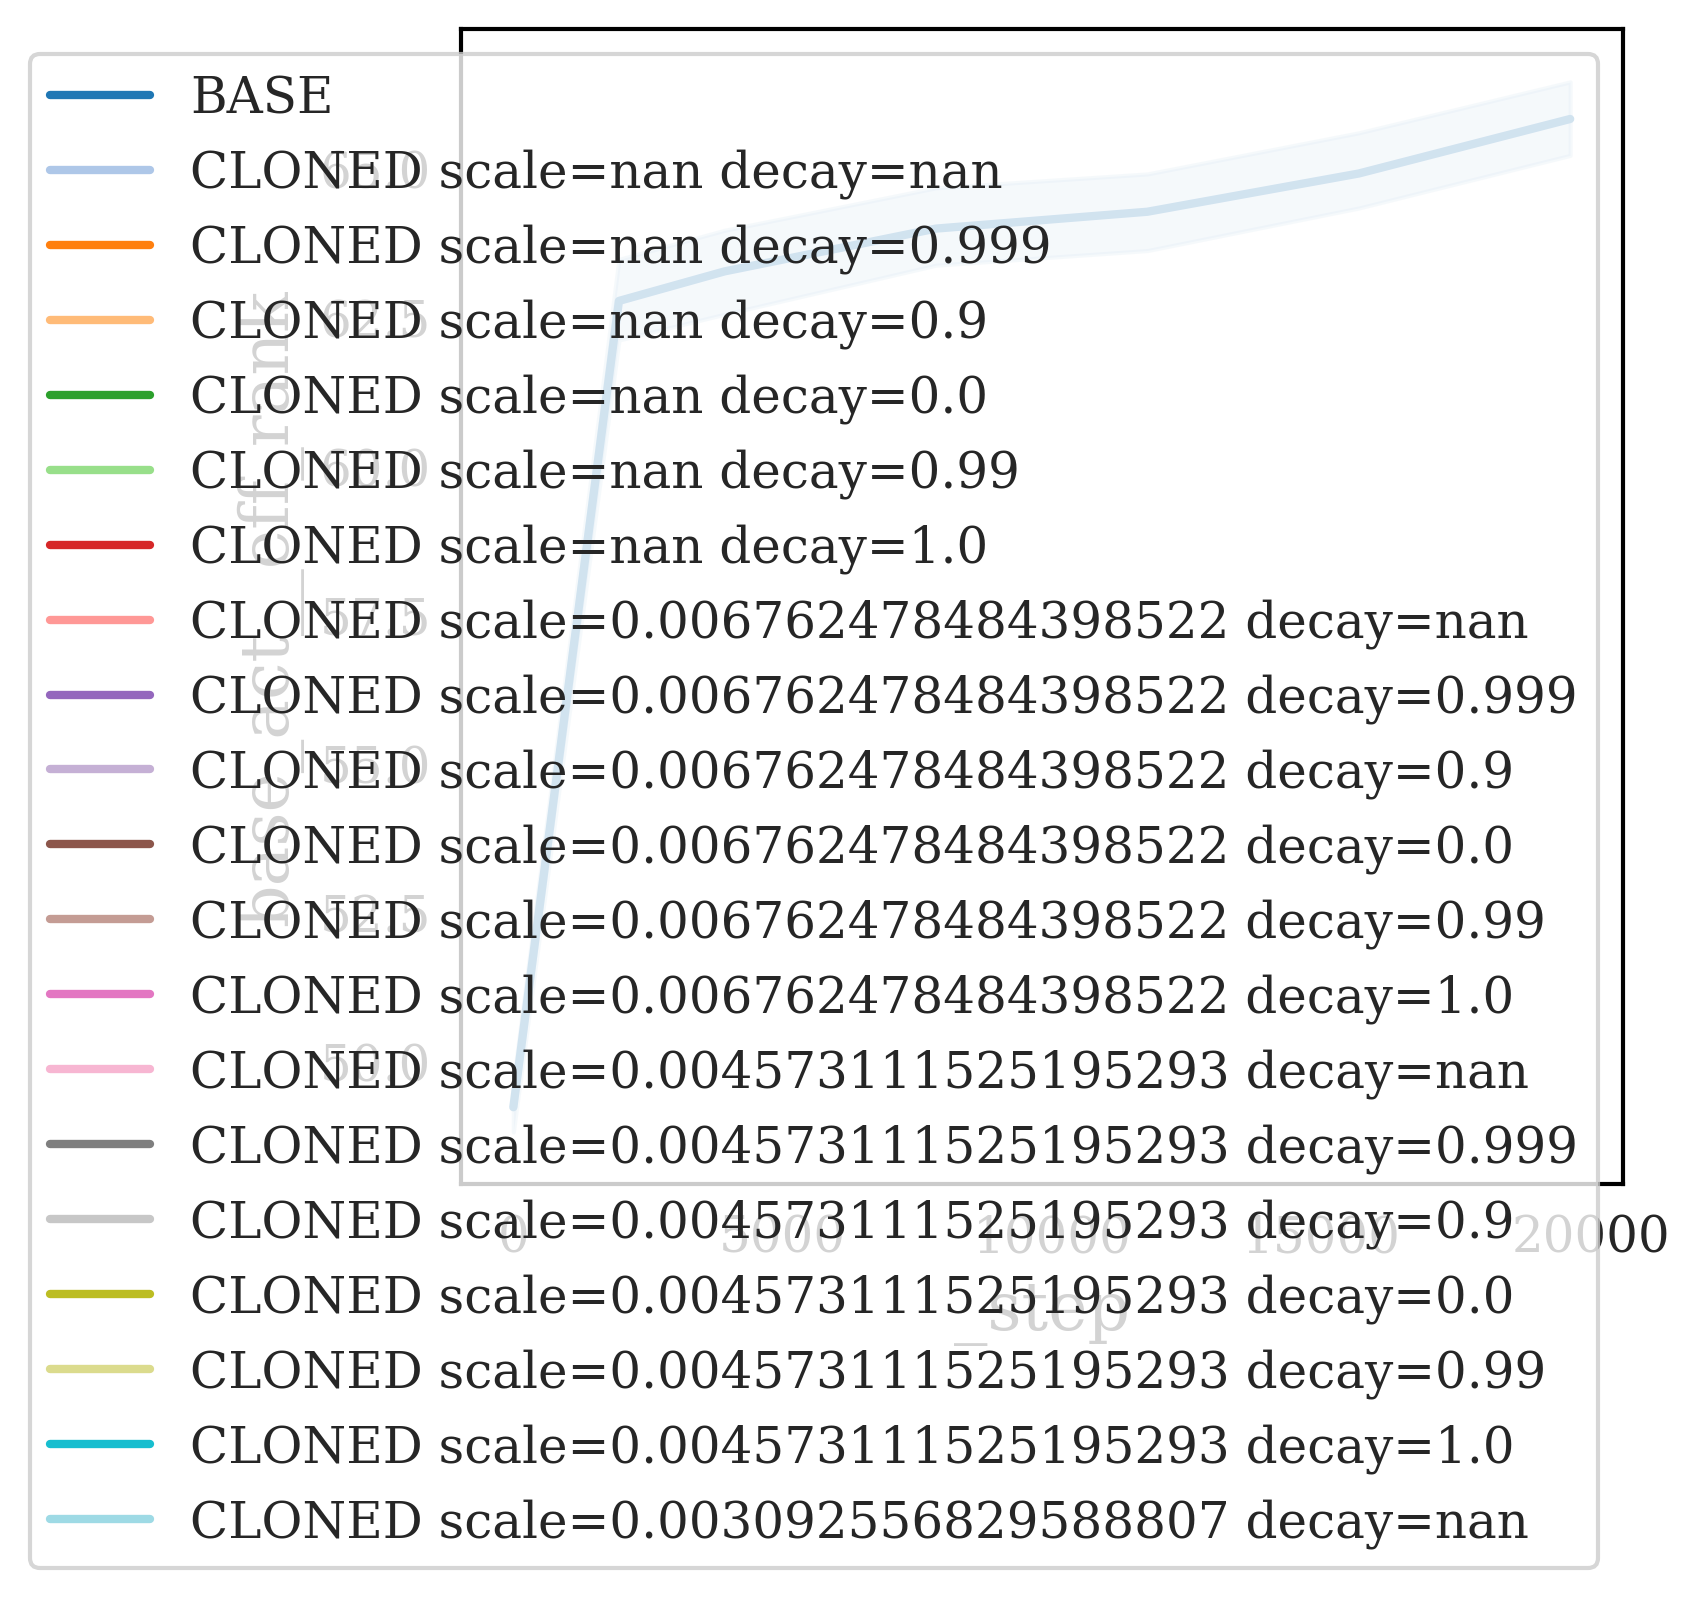

In [69]:
# Create a custom palette with a range of reds and blues
custom_palette = sns.color_palette("tab20", 20)

# Set the palette for the plot
sns.set_palette(custom_palette)

# Create a list of quantities to plot
quantities = ["eff_rank","stable_rank","non_gaussianity","saturated_frac","dead_fraction", "dup_fraction"]
quantities += ["train/loss_step","cloning_score"]


# one style for each normalization
styles = ["-", ":", "--", "-."]
markers = ["o","D"]

total = 0 

# Create the plot
for i,quantity in enumerate(quantities):
       
    plt.figure(figsize=(5,5), dpi=300)  # Increase the plot size

    # df = sample_dataframe_equally(df_avg, "run_id", 0.5)

    if i==len(quantities)-2:
        col_base = "base_train_loss"
        col_cloned = "cloned_train/loss"
    elif i==len(quantities)-1:
        col_cloned = "cloned_2x_train/cloning_r2/mean"
    else:
        col_base = f"base_act__{quantity}"
        col_cloned = f"cloned_act__{quantity}"

    # plot the base model first 
    if i<len(quantities)-1: 
        sns.lineplot(data=df_avg, x="_step", y=f'{col_base}', linewidth=2, color=custom_palette[0], linestyle="-", label=f"BASE")

    # plot all model configurations
    for s, scale in enumerate(df_avg["noise_scale"].unique()):
        for d, decay in enumerate(df_avg["noise_decay"].unique()):
            
            total+=1 

            df = df_avg[(df_avg["noise_scale"] == scale) & (df_avg["noise_decay"] == decay)]

            # plot the cloned model 
            sns.lineplot(data=df, x="_step", y=col_cloned, linewidth=2, color=custom_palette[total], linestyle="-", label=f"CLONED scale={scale} decay={decay}")


    plt.grid(True, linestyle='--', alpha=0.7)   
    plt.xlabel("Step")
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'../paper/images/CBP-{"loss"}.pdf', format='pdf', dpi=300, bbox_inches='tight')

    plt.show()


In [72]:
total=0
for s, scale in enumerate(df_avg["noise_scale"].unique()):
    for d, decay in enumerate(df_avg["noise_decay"].unique()):
        print(scale, decay)
        total+=1

print(total)


nan nan
nan 0.999
nan 0.9
nan 0.0
nan 0.99
nan 1.0
0.006762478484398522 nan
0.006762478484398522 0.999
0.006762478484398522 0.9
0.006762478484398522 0.0
0.006762478484398522 0.99
0.006762478484398522 1.0
0.004573111525195293 nan
0.004573111525195293 0.999
0.004573111525195293 0.9
0.004573111525195293 0.0
0.004573111525195293 0.99
0.004573111525195293 1.0
0.003092556829588807 nan
0.003092556829588807 0.999
0.003092556829588807 0.9
0.003092556829588807 0.0
0.003092556829588807 0.99
0.003092556829588807 1.0
0.0020913349021874014 nan
0.0020913349021874014 0.999
0.0020913349021874014 0.9
0.0020913349021874014 0.0
0.0020913349021874014 0.99
0.0020913349021874014 1.0
0.001414260727971399 nan
0.001414260727971399 0.999
0.001414260727971399 0.9
0.001414260727971399 0.0
0.001414260727971399 0.99
0.001414260727971399 1.0
0.0009563907744236375 nan
0.0009563907744236375 0.999
0.0009563907744236375 0.9
0.0009563907744236375 0.0
0.0009563907744236375 0.99
0.0009563907744236375 1.0
0.00064675720347170

3.3728883064977095e-21 nan
3.3728883064977095e-21 0.999
3.3728883064977095e-21 0.9
3.3728883064977095e-21 0.0
3.3728883064977095e-21 0.99
3.3728883064977095e-21 1.0
6.627703133503032e-23 nan
6.627703133503032e-23 0.999
6.627703133503032e-23 0.9
6.627703133503032e-23 0.0
6.627703133503032e-23 0.99
6.627703133503032e-23 1.0
1.302339266355891e-24 nan
1.302339266355891e-24 0.999
1.302339266355891e-24 0.9
1.302339266355891e-24 0.0
1.302339266355891e-24 0.99
1.302339266355891e-24 1.0
2.5590880136418296e-26 nan
2.5590880136418296e-26 0.999
2.5590880136418296e-26 0.9
2.5590880136418296e-26 0.0
2.5590880136418296e-26 0.99
2.5590880136418296e-26 1.0
5.0285909599347485e-28 nan
5.0285909599347485e-28 0.999
5.0285909599347485e-28 0.9
5.0285909599347485e-28 0.0
5.0285909599347485e-28 0.99
5.0285909599347485e-28 1.0
9.881147857182142e-30 nan
9.881147857182142e-30 0.999
9.881147857182142e-30 0.9
9.881147857182142e-30 0.0
9.881147857182142e-30 0.99
9.881147857182142e-30 1.0
1.9416389949673337e-31 nan
1

In [74]:
heatmap_data

,noise_scale,noise_decay,cloned_2x_train/cloning_r2/mean
0,0.000000e+00,0.000,NaN
1,0.000000e+00,0.900,NaN
2,7.078810e-307,0.900,NaN
3,1.415762e-306,0.900,NaN
4,5.509841e-289,0.900,NaN
...,...,...,...
113,6.762478e-03,0.999,NaN
114,9.146223e-03,0.999,NaN
115,1.000000e-02,1.000,NaN
116,1.352496e-02,0.999,NaN


In [75]:
df_avg['cloned_2x_train/cloning_r2/mean']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
980845        NaN
980846        NaN
980847    0.23109
980848        NaN
980849        NaN
Name: cloned_2x_train/cloning_r2/mean, Length: 980850, dtype: float64

In [77]:
import numpy as np 

In [97]:
main_df[(main_df['noise_scale'] == scale)]

,base_train/layers.norm_0/mean_of_stds,base_val/layers.linear_3/std_of_means,base_train/layers.norm_2/act_means_hist,base_train/layers.linear_0/act_stds_hist,base_val/layers.linear_2/std_of_stds,base_val/layers.linear_3/mean_of_means,base_val/layers.norm_4/std_of_stds,base_train/layers.linear_1/std_of_stds,base_val/layers.linear_3/act_means_hist,base_train/layers.norm_3/act_stds_hist,...,act__mean_of_stds,act__std_of_stds,act__dead_fraction,act__saturated_frac,act__dup_fraction,act__std_of_means,act__mean_of_means,act__stable_rank,act__non_gaussianity,act__eff_rank
200877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
978493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
980061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unique noise scales: [np.float64(nan), np.float64(0.0), np.float64(7.078809795634507e-307), np.float64(1.4157619591269014e-306), np.float64(5.50984082261498e-289), np.float64(1.101968164522996e-288), np.float64(4.288622913597209e-271), np.float64(8.577245827194418e-271), np.float64(3.3380794631199525e-253), np.float64(6.676158926239905e-253), np.float64(2.5982173594173297e-235), np.float64(5.1964347188346594e-235), np.float64(2.0223405468208815e-217), np.float64(4.044681093641763e-217), np.float64(1.5741028257285468e-199), np.float64(3.1482056514570936e-199), np.float64(1.225213878968948e-181), np.float64(2.450427757937896e-181), np.float64(9.536537414722922e-164), np.float64(1.9073074829445843e-163), np.float64(7.4228302032412e-146), np.float64(1.48456604064824e-145), np.float64(5.777611498811558e-128), np.float64(1.1555222997623115e-127), np.float64(4.497044081194759e-110), np.float64(8.994088162389518e-110), np.float64(3.5003055280488706e-92), np.float64(7.000611056097741e-92), np.f

Scale 1.4157619591269014e-306, Decay 0.9: 0 valid values, mean = nan
Scale 5.50984082261498e-289, Decay 0.9: 0 valid values, mean = nan
Scale 1.101968164522996e-288, Decay 0.9: 0 valid values, mean = nan
Scale 4.288622913597209e-271, Decay 0.9: 0 valid values, mean = nan
Scale 8.577245827194418e-271, Decay 0.9: 0 valid values, mean = nan
Scale 3.3380794631199525e-253, Decay 0.9: 0 valid values, mean = nan
Scale 6.676158926239905e-253, Decay 0.9: 0 valid values, mean = nan
Scale 2.5982173594173297e-235, Decay 0.9: 0 valid values, mean = nan
Scale 5.1964347188346594e-235, Decay 0.9: 0 valid values, mean = nan
Scale 2.0223405468208815e-217, Decay 0.9: 0 valid values, mean = nan
Scale 4.044681093641763e-217, Decay 0.9: 0 valid values, mean = nan
Scale 1.5741028257285468e-199, Decay 0.9: 0 valid values, mean = nan
Scale 3.1482056514570936e-199, Decay 0.9: 0 valid values, mean = nan
Scale 1.225213878968948e-181, Decay 0.9: 0 valid values, mean = nan
Scale 2.450427757937896e-181, Decay 0.9: 0

/media/hofmann-scratch/glanzillo/loss-of-plasticity/lop/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/media/hofmann-scratch/glanzillo/loss-of-plasticity/lop/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


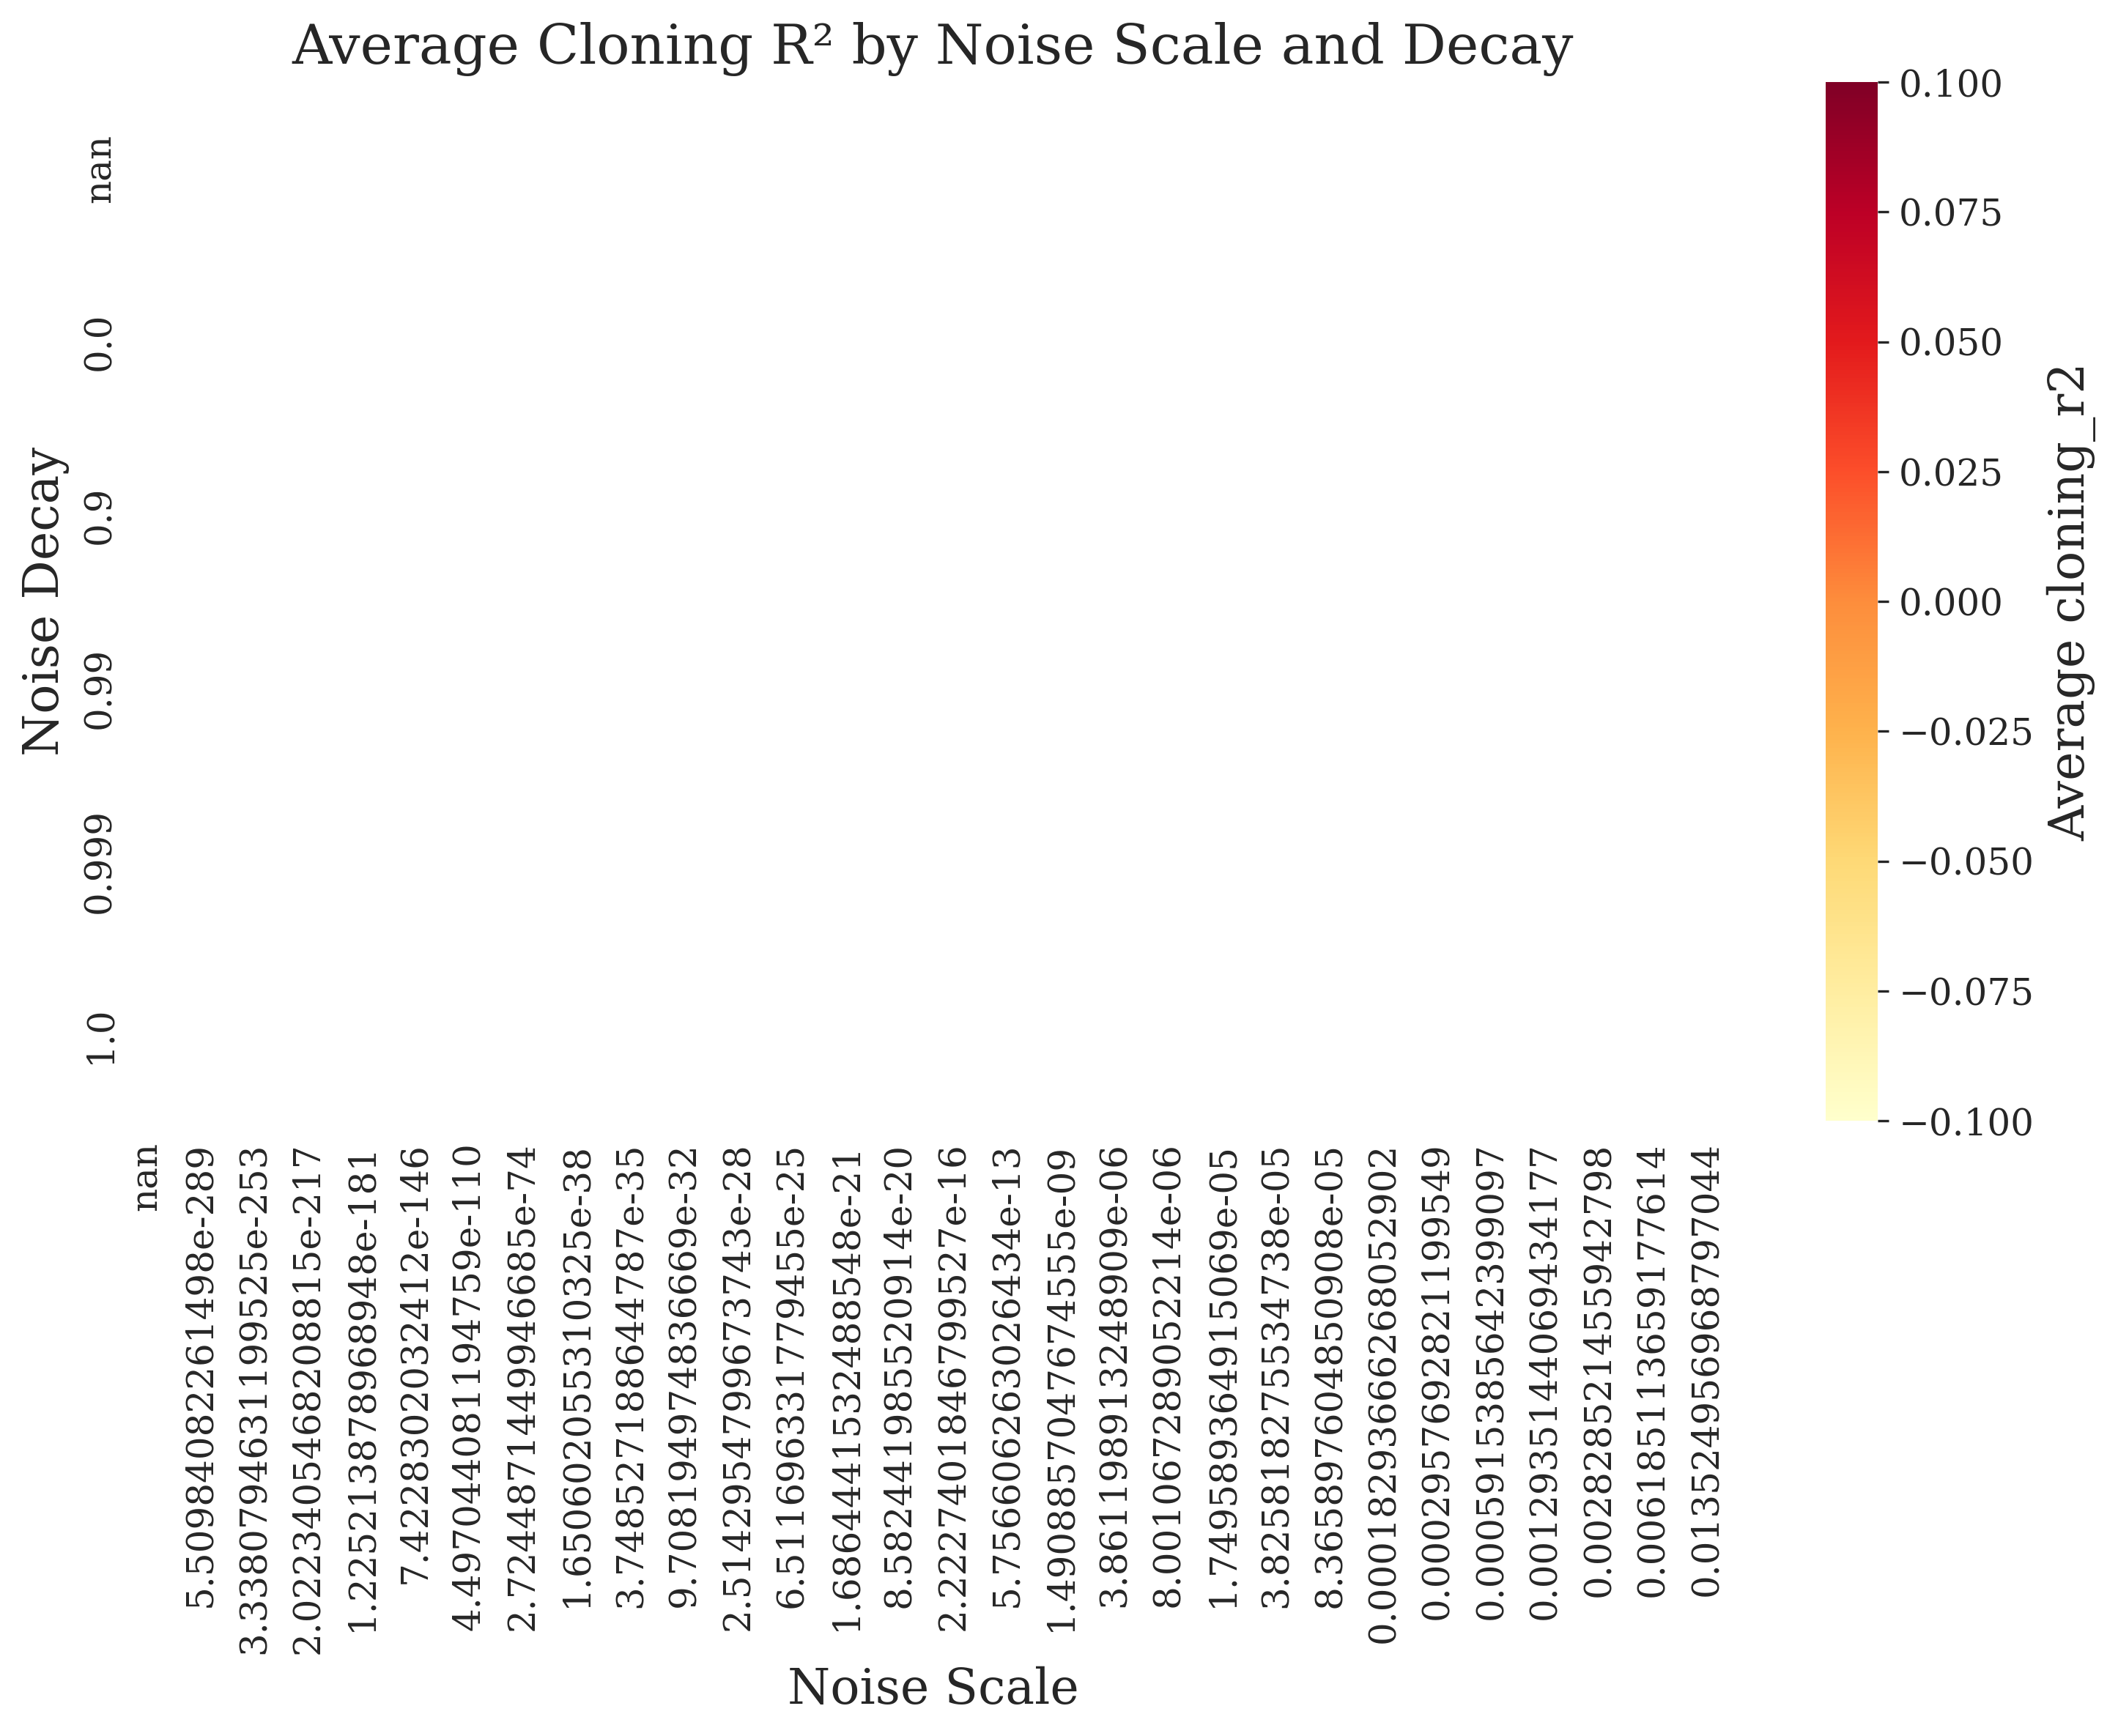

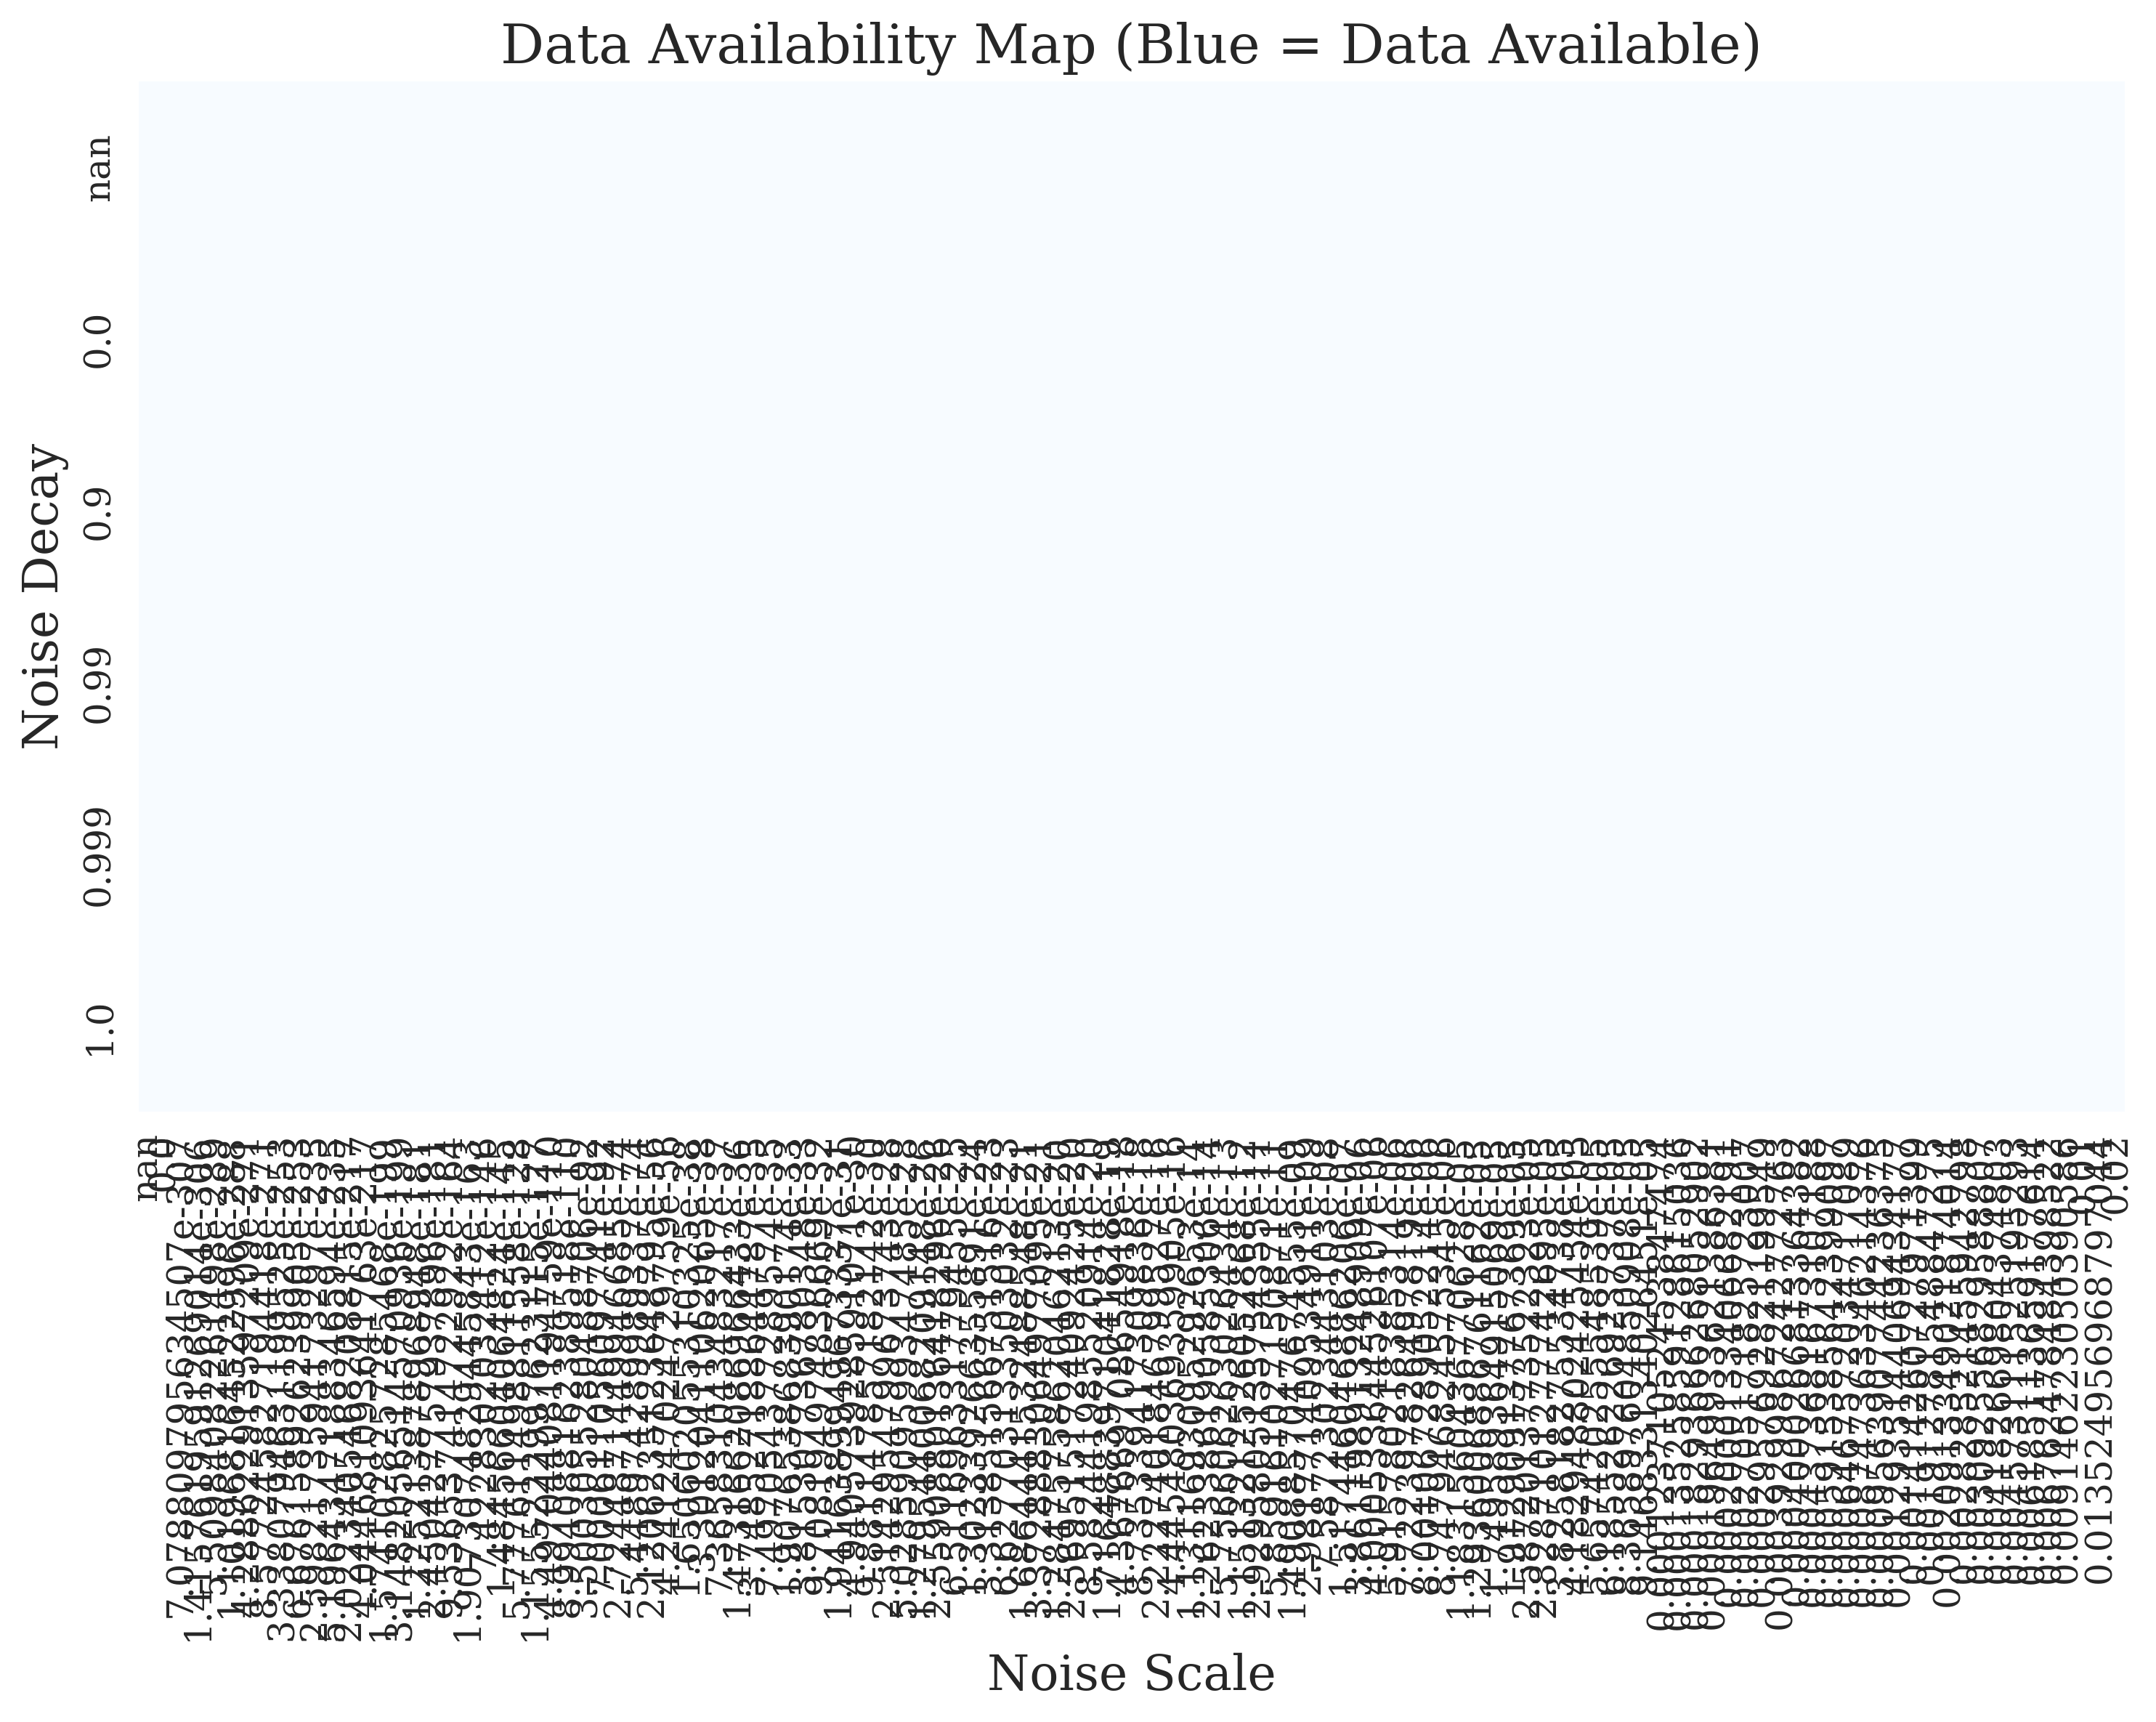

In [91]:
# Get unique values for noise_scale and noise_decay
scales = sorted(df_avg['noise_scale'].unique())
decays = sorted(df_avg['noise_decay'].unique())

print(f"Unique noise scales: {scales}")
print(f"Unique noise decays: {decays}")

# Create an empty matrix to store our results
result_matrix = np.zeros((len(decays), len(scales)))
result_matrix[:] = np.nan  # Initialize with NaN

# Iterate through all combinations and calculate mean
for i, decay in enumerate(decays):
    for j, scale in enumerate(scales):
        # Filter data for this combination
        subset = df_avg[(df_avg['noise_scale'] == scale) & (df_avg['noise_decay'] == decay)]
        
        # Calculate mean, ignoring NaN values
        values = subset['cloned_2x_train/cloning_r2/mean'].dropna()
        
        if len(values) > 0:
            result_matrix[i, j] = values.mean()
        
        print(f"Scale {scale}, Decay {decay}: {len(values)} valid values, mean = {result_matrix[i, j]}")

# Create a DataFrame from the matrix for better visualization
heatmap_df = pd.DataFrame(result_matrix, index=decays, columns=scales)
print("\nResulting matrix:")
print(heatmap_df)

# Plot the heatmap
plt.figure(figsize=(10, 8), dpi=300)
ax = sns.heatmap(heatmap_df, 
                 annot=True,  # Show values in each cell
                 fmt=".3f",   # Format for the annotations
                 cmap="YlOrRd",  # Color map
                 linewidths=.5,
                 cbar_kws={'label': 'Average cloning_r2'})

plt.title('Average Cloning R² by Noise Scale and Decay')
plt.xlabel('Noise Scale')
plt.ylabel('Noise Decay')
plt.tight_layout()
plt.show()

# If you want to see where we have data and where we don't
plt.figure(figsize=(10, 8), dpi=300)
mask = np.isnan(result_matrix)
sns.heatmap(~mask, cmap='Blues', cbar=False)
plt.title('Data Availability Map (Blue = Data Available)')
plt.xlabel('Noise Scale')
plt.ylabel('Noise Decay')
plt.xticks(np.arange(len(scales)) + 0.5, scales)
plt.yticks(np.arange(len(decays)) + 0.5, decays)
plt.tight_layout()
plt.show()

In [92]:
subset

,base_train/layers.norm_0/mean_of_stds,base_val/layers.linear_3/std_of_means,base_train/layers.norm_2/act_means_hist,base_train/layers.linear_0/act_stds_hist,base_val/layers.linear_2/std_of_stds,base_val/layers.linear_3/mean_of_means,base_val/layers.norm_4/std_of_stds,base_train/layers.linear_1/std_of_stds,base_val/layers.linear_3/act_means_hist,base_train/layers.norm_3/act_stds_hist,...,cloned_act__std_of_stds,cloned_act__non_gaussianity,cloned_act__mean_of_stds,cloned_act__std_of_means,cloned_act__dup_fraction,cloned_act__mean_of_means,cloned_act__saturated_frac,cloned_act__eff_rank,cloned_act__dead_fraction,cloned_act__stable_rank
200877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
978493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
980061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df_avg.dropna(subset=['cloned_2x_train/cloning_r2/mean'])

,base_train/layers.norm_0/mean_of_stds,base_val/layers.linear_3/std_of_means,base_train/layers.norm_2/act_means_hist,base_train/layers.linear_0/act_stds_hist,base_val/layers.linear_2/std_of_stds,base_val/layers.linear_3/mean_of_means,base_val/layers.norm_4/std_of_stds,base_train/layers.linear_1/std_of_stds,base_val/layers.linear_3/act_means_hist,base_train/layers.norm_3/act_stds_hist,...,cloned_act__std_of_stds,cloned_act__non_gaussianity,cloned_act__mean_of_stds,cloned_act__std_of_means,cloned_act__dup_fraction,cloned_act__mean_of_means,cloned_act__saturated_frac,cloned_act__eff_rank,cloned_act__dead_fraction,cloned_act__stable_rank
3923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
969078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
973001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
976924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df_clean.groupby(['noise_scale', 'noise_decay'])['cloned_2x_train/cloning_r2/mean'].mean()

Series([], Name: cloned_2x_train/cloning_r2/mean, dtype: float64)